# Recover Masked Time Points in Zebrafish Embryogenesis
CellDyc is applied to the axial-mesoderm lineage of zebrafish embryos (See details <span style="color: darkblue;">[here](datasets.rst#celldyc.datasets.core.zebrafish)</span>) using data from 12 time points (3.3–12 hours post-fertilization). We first evaluate CellDyc's performance on the complete dataset containing all 12 time points. Subsequently, we down-sample the dataset to 6 time points for training and apply the trained model back to the full dataset.

## Import Packages

In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
import celldyc as cdc

## Load the Data
The analysis is based on in-built Zebrafish dataset. 

In [3]:
adata = cdc.datasets.zebrafish()
adata

AnnData object with n_obs × n_vars = 2341 × 23974
    obs: 'Stage', 'gt_terminal_states', 'lineages'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors'
    obsm: 'X_force_directed'

This dataset contains cells from 12 time points.  

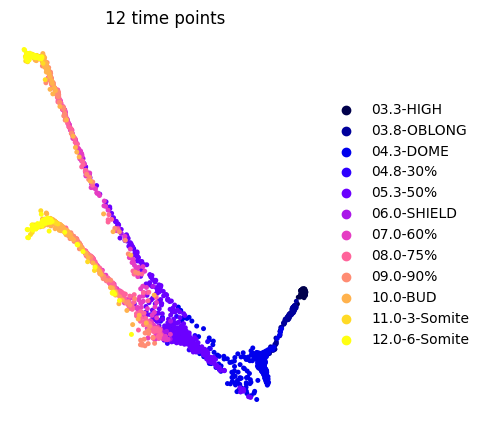

In [4]:
fig, ax = plt.subplots(figsize=(4,5))
sc.pl.embedding(adata, color="Stage", basis="force_directed", ax=ax,title="12 time points",frameon=False)

## Preprocess the Data

In [5]:
adata = cdc.tl.preprocess(adata)
adata

AnnData object with n_obs × n_vars = 2341 × 2000
    obs: 'Stage', 'gt_terminal_states', 'lineages'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_force_directed', 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

We transform descriptive time point strings into numerical format.

In [6]:
cat_map = {'03.3-HIGH': 03.3,
           '03.8-OBLONG': 03.8,
           '04.3-DOME': 04.3,
           '04.8-30%':04.8,
           '05.3-50%':05.3,
           '06.0-SHIELD':06.0,
           '07.0-60%':07.0,
           '08.0-75%':08.0,
           '09.0-90%':09.0,
           '10.0-BUD':10.0,
           '11.0-3-Somite':11.0,
           '12.0-6-Somite':12.0}
adata.obs['numerical_time'] = adata.obs['Stage'].map(cat_map).astype('category')


## Estimation of Time Representation and Transcriptomic Velocity with all 12 time points

We first train CellDyc using the `recover_dyc` function. By default, predicted velocities are stored in **adata.layers['velocity']**, and predicted gene-embedded time values are stored in **adata.obs['getime']**.

In [7]:
cdc.tl.recover_dyc(adata, time_key='numerical_time')

Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.837947,trend_loss=0.828511,time_loss=0.094358
epoch  51:loss=0.425178,trend_loss=0.424160,time_loss=0.010178
epoch 101:loss=0.385324,trend_loss=0.384423,time_loss=0.009003
epoch 151:loss=0.377774,trend_loss=0.376906,time_loss=0.008671
epoch 201:loss=0.373027,trend_loss=0.372226,time_loss=0.008010
epoch 251:loss=0.352568,trend_loss=0.351829,time_loss=0.007390
Early stopping at epoch 299


AnnData object with n_obs × n_vars = 2341 × 2000
    obs: 'Stage', 'gt_terminal_states', 'lineages', 'numerical_time', 'getime'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'getime_weights'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_force_directed', 'X_pca'
    varm: 'PCs'
    layers: 'velocity'
    obsp: 'distances', 'connectivities'

We generated a violin plot of gene-embedded time versus sampling time points, which shows that the learned time respects the actual temporal order.

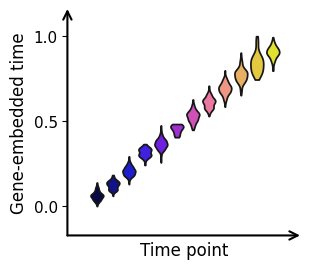

<Axes: xlabel='Time point', ylabel='Gene-embedded time'>

In [8]:
cdc.pl.getime_violin(adata, 'getime', 'numerical_time',palette='gnuplot2')

We then project the velocities onto the force-directed embedding.

  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


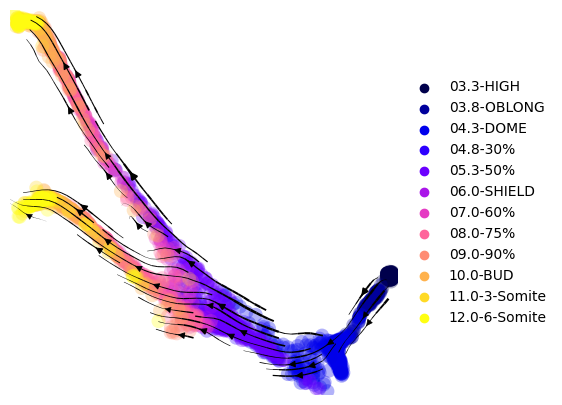

computing velocity embedding
finished.


In [9]:
cdc.pl.plot_velocity_projection(adata,basis='force_directed', color='Stage',figsize=(5,5),legend_loc="right")

## Estimation of Time Representation and Transcriptomic Velocity with 6 time points

In [10]:
adata_ = cdc.datasets.zebrafish()
adata_.obs['numerical_time'] = adata_.obs['Stage'].map(cat_map).astype('category')
sc.pp.filter_genes(adata_, min_cells=10)
sc.pp.normalize_total(adata_, target_sum=1e4)
sc.pp.log1p(adata_)
sc.pp.highly_variable_genes(adata_, n_top_genes=2000)
adata_ = adata_[:, adata_.var.highly_variable].copy()

We select subsets at six time points.

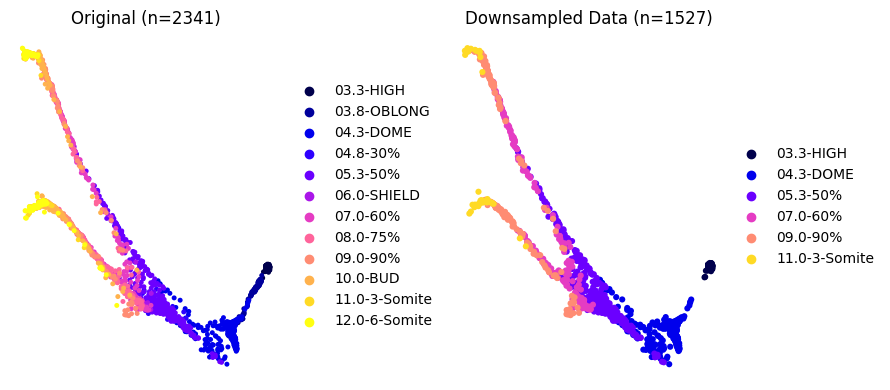

In [11]:
keep = ['03.3-HIGH','04.3-DOME','05.3-50%','07.0-60%','09.0-90%','11.0-3-Somite']
adata_subset = adata_[adata_.obs['Stage'].isin(keep)].copy()
fig, axes = plt.subplots(1, 2, figsize=(9,4))
sc.pl.embedding(
    adata, 
    basis='force_directed', 
    color='Stage', 
    ax=axes[0], 
    title=f'Original (n={adata.n_obs})',
    show=False,frameon=False
)
sc.pl.embedding(
    adata_subset, 
    basis='force_directed', 
    color='Stage', 
    ax=axes[1], 
    title=f'Downsampled Data (n={adata_subset.n_obs})',
    show=False,frameon=False
)
plt.tight_layout()
plt.show()

sc.tl.pca(adata_subset, svd_solver='arpack')
sc.pp.neighbors(adata_subset, n_neighbors=30, n_pcs=30)

sc.tl.pca(adata_, svd_solver='arpack')
sc.pp.neighbors(adata_, n_neighbors=30, n_pcs=30)

We then train CellDyc on the downsampled **adata_sub** and save the trained model to **save_path**.

In [12]:
cdc.tl.recover_dyc(adata_subset,time_key="numerical_time", save_path='zebrafish.pt')

Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.876759,trend_loss=0.862731,time_loss=0.140287
epoch  51:loss=0.313247,trend_loss=0.312212,time_loss=0.010346
epoch 101:loss=0.270490,trend_loss=0.269659,time_loss=0.008309
epoch 151:loss=0.259464,trend_loss=0.258694,time_loss=0.007700
epoch 201:loss=0.244994,trend_loss=0.244285,time_loss=0.007091
epoch 251:loss=0.245265,trend_loss=0.244603,time_loss=0.006618
Early stopping at epoch 256


AnnData object with n_obs × n_vars = 1527 × 2000
    obs: 'Stage', 'gt_terminal_states', 'lineages', 'numerical_time', 'getime'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'getime_weights'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_force_directed', 'X_pca'
    varm: 'PCs'
    layers: 'velocity'
    obsp: 'distances', 'connectivities'

Next, we apply this saved model to the full 12 time points dataset.

In [13]:
cdc.tl.recover_dyc(adata_, time_key='numerical_time', model_path='zebrafish.pt')

AnnData object with n_obs × n_vars = 2341 × 2000
    obs: 'Stage', 'gt_terminal_states', 'lineages', 'numerical_time', 'getime'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'getime_weights'
    uns: 'Stage_colors', 'gt_terminal_states_colors', 'lineages_colors', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_force_directed', 'X_pca'
    varm: 'PCs'
    layers: 'velocity'
    obsp: 'distances', 'connectivities'

Here, we generate a violin plot of gene-embedded time versus sampling time points, showing that the model—trained on only 6 time points—learns a time representation that respects the actual temporal order across all 12 time points.

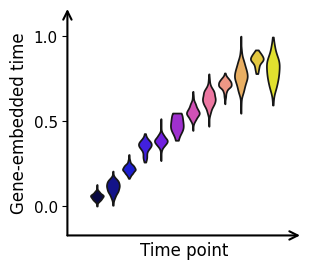

<Axes: xlabel='Time point', ylabel='Gene-embedded time'>

In [14]:
cdc.pl.getime_violin(adata_, 'getime', 'numerical_time',palette='gnuplot2')

Finally, we project the velocities onto the force-directed embedding.

  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


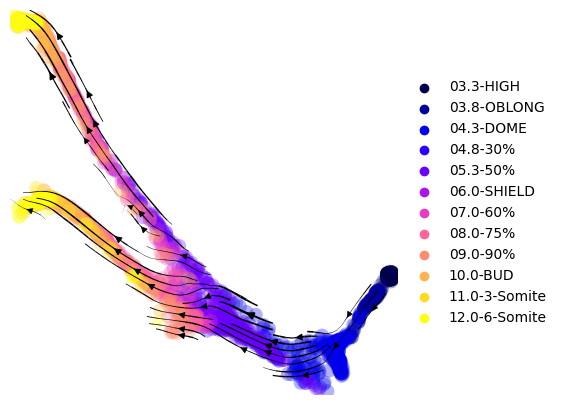

computing velocity embedding
finished.


In [15]:
cdc.pl.plot_velocity_projection(adata_,basis='force_directed', color='Stage', legend_loc='right',figsize=(5,5))